In [27]:
import sklearn
from sklearn.datasets import make_circles

In [28]:
n_sample=1000
x,y=make_circles(n_samples=n_sample,noise=0.05,random_state=42)


In [29]:
len(x),len(y) ,x.shape

(1000, 1000, (1000, 2))

In [30]:
x[:5] , y[:5]

(array([[ 0.74220688,  0.24668576],
        [-0.7340323 ,  0.16869164],
        [-0.82985872,  0.22195899],
        [-0.42913559,  0.67223019],
        [ 0.44560223, -0.89493556]]),
 array([1, 1, 1, 1, 0]))

In [31]:
import pandas as pd

circle=pd.DataFrame({"x1":x[:,0],
                     "x2":x[:,1],
                     "label":y})

In [32]:
circle.head()

,x1,x2,label
0,0.742207,0.246686,1
1,-0.734032,0.168692,1
2,-0.829859,0.221959,1
3,-0.429136,0.672230,1
4,0.445602,-0.894936,0


In [33]:
circle['label'].value_counts()

label
1    500
0    500
Name: count, dtype: int64

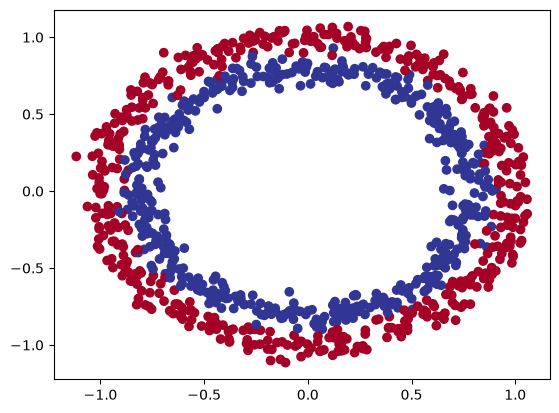

In [34]:
import matplotlib.pyplot as plt 
plt.scatter(x=circle["x1"] , y=circle['x2'],c=y,cmap=plt.cm.RdYlBu )

In [35]:
x.shape , y.shape

((1000, 2), (1000,))

In [36]:
import torch
print(type(x)) 
print(x.dtype)
x=torch.from_numpy(x).type(torch.float32)
y=torch.from_numpy(y).type(torch.float32)

<class 'numpy.ndarray'>
float64


In [37]:
type(x) , x.dtype

(torch.Tensor, torch.float32)

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state= 42 , shuffle=True)

In [39]:
len(x_train) , len(y_train) , len(x_test) , len(y_test)

(800, 800, 200, 200)

In [40]:
from torch import nn
import torch


In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [42]:
from torch import nn

class CirleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.Layer1=nn.Linear(2,5)
        self.Layer2=nn.Linear(5,1)
    def forward(self,x:torch.tensor) -> torch.tensor:
        return self.Layer2(self.Layer1(x))

model_0=CirleModel()
model_0.to(device)
model_0

CirleModel(
  (Layer1): Linear(in_features=2, out_features=5, bias=True)
  (Layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [43]:
# Another way to build neural network 
model_0=nn.Sequential(
    nn.Linear(2,5),
    nn.Linear(5,1),
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [44]:
"""
X_test -> y_test
"""
untrained_preds = model_0(x_test.to(device))
print(f"this is the shape of the untrained models predictions : {untrained_preds. shape}")
print(f"this is the real targets shape : {y_test. shape}")

this is the shape of the untrained models predictions : torch.Size([200, 1])
this is the real targets shape : torch.Size([200])


In [45]:

print(f"this is the untrained model predictions : {untrained_preds[:5]}")
# if we use torch.round we would get something similar to the real targets
print(f"this is the real targets : {y_test[:5]} ")

this is the untrained model predictions : tensor([[-0.0307],
        [-0.0213],
        [ 0.0896],
        [-0.0678],
        [ 0.3020]], device='cuda:0', grad_fn=<SliceBackward0>)
this is the real targets : tensor([1., 0., 1., 0., 1.]) 


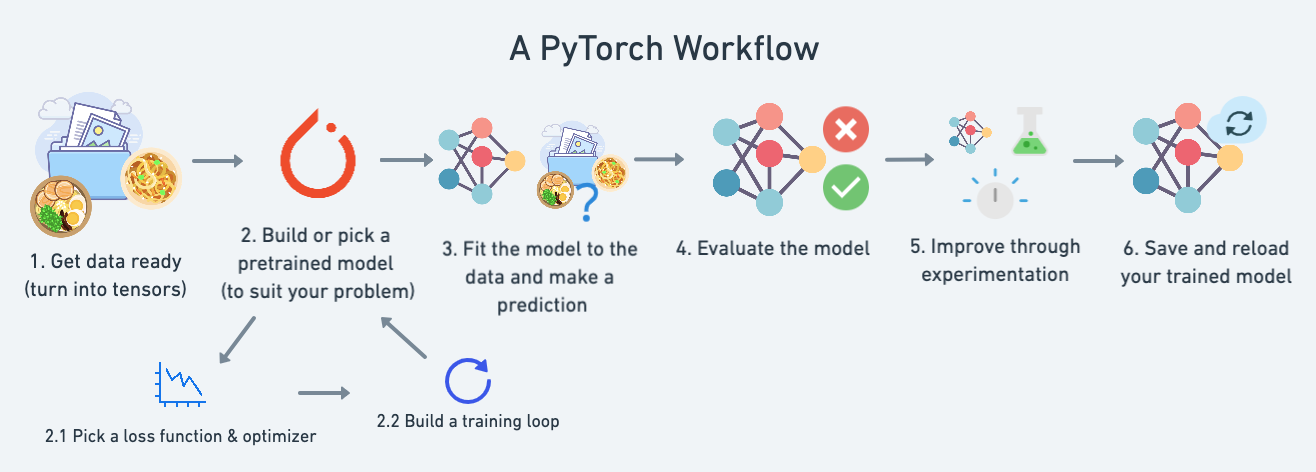

## Lets dig deeper into loss functions and optimizers
1. loss_functions -> https://pytorch.org/docs/stable/nn.html#loss-functions
2. optimizers -> https://pytorch.org/docs/stable/optim.html

`BCELoss()`

Used for Binary Classification.
It takes probabilities between 0 and 1.
You need to apply Sigmoid() before it.

`BCEWithLogitsLoss()`
Used for Binary Classification.
It takes raw logits and applies Sigmoid internally.
It is more numerically stable than Sigmoid + BCELoss.

`CrossEntropyLoss()`
Used for Multi-Class Classification.
It takes raw logits for all classes and applies Softmax internally.
You should not apply Softmax before it.

## *So to sum this up we have a few steps to consider*


`logits` -> `preds prob` -> `round preds labels`
binary classification we use sigmoid
multi class classification we use softmax

In [46]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(params=model_0.parameters(), lr=0.01)

In [47]:
untrained_preds.shape

torch.Size([200, 1])

In [48]:
untrained_preds[:5,:]

tensor([[-0.0307],
        [-0.0213],
        [ 0.0896],
        [-0.0678],
        [ 0.3020]], device='cuda:0', grad_fn=<SliceBackward0>)

In [49]:
sigmoid_output_2 = torch.sigmoid(untrained_preds[:5])
sigmoid_output_2

tensor([[0.4923],
        [0.4947],
        [0.5224],
        [0.4831],
        [0.5749]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [50]:
output_after_sigmoid = torch.round(sigmoid_output_2)
output_after_sigmoid

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]], device='cuda:0', grad_fn=<RoundBackward0>)

`tensor` = [1,1,1,1,1] -> this is the output of the model
`ground truth tensor` = [1,0,1,1,0]

`acc` = 2/5 -> 60 % acc

In [51]:
def accuracy(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum()
    acc=(correct/len(y_true))*100
    return acc
x_p = torch.tensor([1,1,1,1,1])
x_t = torch.tensor([1,0,1,1,0])

accuracy(y_true=x_t,y_pred=x_p)

tensor(60.0000)

# Let's Construct a training loop
Steps

1.Forward pass  
2.calculate the loss   
3.optimizer zero grad   
4.loss backward()   
5.optimizer.step()   

In [52]:
x_train.shape

torch.Size([800, 2])

In [53]:
y_logits=model_0(x_train.to(device)).squeeze()
y_logits[:5]

tensor([ 0.2818,  0.3197,  0.0157,  0.0429, -0.0288], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [54]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs=100
x_train , y_train , x_test , y_test =x_train.to(device) , y_train.to(device) , x_test.to(device) , y_test.to(device) 

for epoch in range(epochs):
    model_0.train()
    y_logits=model_0(x_train).squeeze()
    y_pred=torch.round(torch.sigmoid(y_logits))
    loss=loss_fn(y_logits,y_train)
    acc=accuracy(y_train,y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model_0.eval()

    with torch.inference_mode():
        test_logits=model_0(x_test).squeeze()
        test_pred=torch.round(torch.sigmoid(test_logits))
        test_loss=loss_fn(test_logits,test_pred)
        test_acc = accuracy(y_true=y_test,y_pred=test_pred) 
          # logging .. print out what's happeing
    if epoch % 10 == 0:
        print(f"Epoch : {epoch} | Loss : {loss:.5f} | Train Accuracy : {acc:.2f} | Test Loss : {test_loss:.5f} | Test Accuracy : {test_acc:.2f}")




Epoch : 0 | Loss : 0.69802 | Train Accuracy : 52.25 | Test Loss : 0.63953 | Test Accuracy : 56.50
Epoch : 10 | Loss : 0.69343 | Train Accuracy : 50.00 | Test Loss : 0.67484 | Test Accuracy : 40.50
Epoch : 20 | Loss : 0.69313 | Train Accuracy : 51.75 | Test Loss : 0.66286 | Test Accuracy : 47.50
Epoch : 30 | Loss : 0.69305 | Train Accuracy : 50.12 | Test Loss : 0.67135 | Test Accuracy : 46.00
Epoch : 40 | Loss : 0.69300 | Train Accuracy : 52.12 | Test Loss : 0.67796 | Test Accuracy : 47.50
Epoch : 50 | Loss : 0.69299 | Train Accuracy : 50.50 | Test Loss : 0.67918 | Test Accuracy : 46.50
Epoch : 60 | Loss : 0.69298 | Train Accuracy : 51.12 | Test Loss : 0.67530 | Test Accuracy : 47.00
Epoch : 70 | Loss : 0.69298 | Train Accuracy : 51.38 | Test Loss : 0.67550 | Test Accuracy : 46.50
Epoch : 80 | Loss : 0.69298 | Train Accuracy : 51.25 | Test Loss : 0.67661 | Test Accuracy : 45.50
Epoch : 90 | Loss : 0.69298 | Train Accuracy : 51.38 | Test Loss : 0.67665 | Test Accuracy : 46.00


In [55]:
import requests
from pathlib import Path 


`wb` --->افتح الملف للكتابة، والبيانات اللي هتكتبها Binary.

In [56]:
#create utils directory 
utils_dire=Path("utils")
utils_dire.mkdir(parents=True , exist_ok=True)


if (utils_dire / "helper_function.py").is_file():
    print("helper_function already is exists skipping ")
else:
    print("Downloading helper fynction.py")
    request=requests.get('https://raw.githubusercontent.com/Amr-Abdellatif/learn-deep-learning-using-pytorch/refs/heads/main/helper_functions.py')
    with open(utils_dire / 'helper_function.py' , 'wb') as f :
        f.write(request.content)

#https://raw.githubusercontent.com/Amr-Abdellatif/learn-deep-learning-using-pytorch/refs/heads/main/helper_functions.py
# download the helper function script from github


helper_function already is exists skipping 


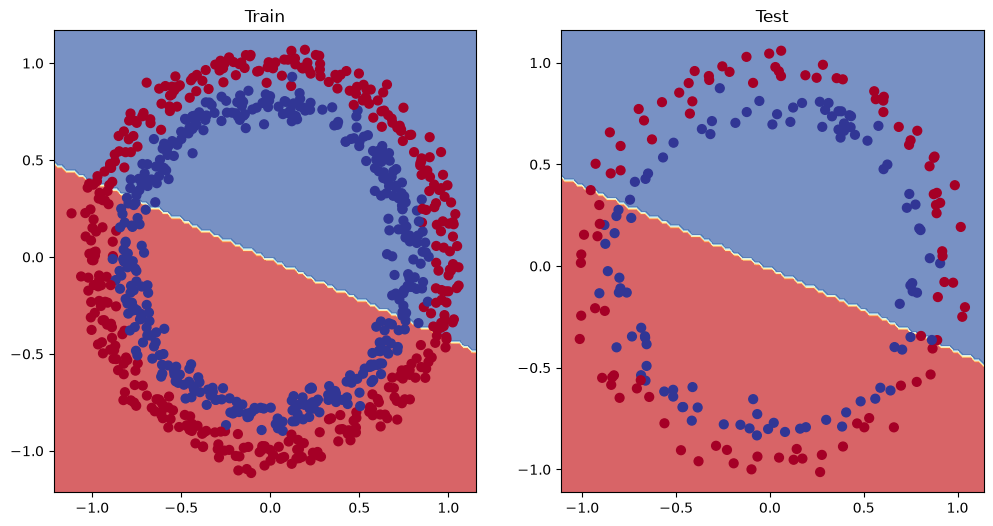

In [57]:
from utils.helper_function import plot_decision_boundary,plot_predictions


# plot decision boundaries for training and test set
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,x_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,x_test,y_test)

In [58]:
# lets build the model we will construct it with three linear layers
"""lets check if adding more linear layers to the model 
    will make the model more robust"""

class CircleModelV1(nn.Module):
    def __init__(self):
        super(CircleModelV1,self).__init__()

        self.layer1 = nn.Linear(2,10)
        self.layer2 = nn.Linear(10,10)
        self.layer3 = nn.Linear(10,1)


    def forward(self,x:torch.Tensor) -> torch.Tensor:
        return self.layer3(self.layer2(self.layer1(x)))
    

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [59]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(), lr = 0.01)

In [60]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set the number of epochs
epochs = 100

# put the data to the target device -> "cuda"
X_train , y_train = x_train.to(device) , y_train.to(device)
X_test , y_test = x_test.to(device) , y_test.to(device)

# Lets start building training loop and evaluation loop
for epoch in range(epochs):
    ## training 
    model_1.train()

    ## 1. Forward pass
    """the raw output of my model is called logits """
    y_logits = model_1(X_train).squeeze()
    
    y_pred = torch.round(torch.sigmoid(y_logits)) # from logits -> pred prob -> pred class labels

    ## 2. calculate the loss
    """BCEwithLogitloss()"""
    loss = loss_fn(y_logits,y_train)

    acc = accuracy(y_true=y_train,y_pred=y_pred) 

    ## 3. optimizer zer grad
    optimizer.zero_grad()

    ## 4. loss backward (back prop)
    loss.backward()

    ## 5. optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        # 1. forward pass
        
        test_logits = model_1(X_test).squeeze()
        
        test_pred = torch.round(torch.sigmoid(test_logits)) # from logits -> pred prob -> pred class labels

        # 2. calculate the loss
        
        test_loss = loss_fn(test_logits,y_test)
        
        test_acc = accuracy(y_true=y_test,y_pred=test_pred) 
    
    # logging .. print out what's happeing
    if epoch % 10 == 0:
        print(f"Epoch : {epoch} | Loss : {loss:.5f} | Train Accuracy : {acc:.2f} | Test Loss : {test_loss:.5f} | Test Accuracy : {test_acc:.2f}")

Epoch : 0 | Loss : 0.69393 | Train Accuracy : 51.00 | Test Loss : 0.69263 | Test Accuracy : 51.00
Epoch : 10 | Loss : 0.69390 | Train Accuracy : 50.87 | Test Loss : 0.69264 | Test Accuracy : 50.00
Epoch : 20 | Loss : 0.69387 | Train Accuracy : 50.62 | Test Loss : 0.69264 | Test Accuracy : 50.00
Epoch : 30 | Loss : 0.69384 | Train Accuracy : 50.50 | Test Loss : 0.69265 | Test Accuracy : 50.00
Epoch : 40 | Loss : 0.69381 | Train Accuracy : 50.75 | Test Loss : 0.69266 | Test Accuracy : 50.00
Epoch : 50 | Loss : 0.69379 | Train Accuracy : 50.50 | Test Loss : 0.69266 | Test Accuracy : 50.50
Epoch : 60 | Loss : 0.69376 | Train Accuracy : 50.25 | Test Loss : 0.69267 | Test Accuracy : 51.00
Epoch : 70 | Loss : 0.69374 | Train Accuracy : 50.12 | Test Loss : 0.69268 | Test Accuracy : 51.00
Epoch : 80 | Loss : 0.69371 | Train Accuracy : 50.25 | Test Loss : 0.69269 | Test Accuracy : 51.00
Epoch : 90 | Loss : 0.69369 | Train Accuracy : 50.25 | Test Loss : 0.69270 | Test Accuracy : 51.00


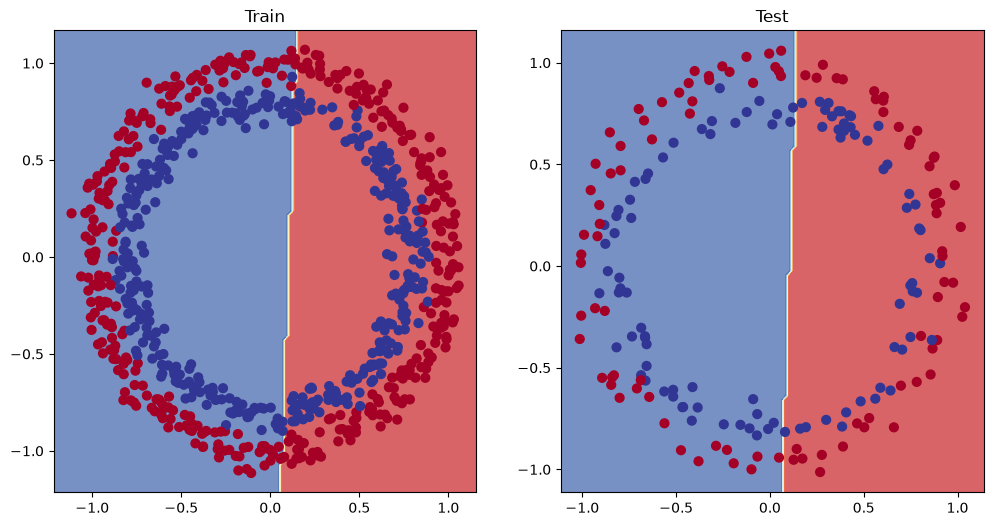

In [61]:

# plot decision boundaries for training and test set
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)

In [62]:
"""we want to use activation functions to introduce non linearity"""

class CircleModelV2(nn.Module):
    def __init__(self):
        super(CircleModelV2,self).__init__()
        self.layer1 = nn.Linear(2,10)
        self.layer2 = nn.Linear(10,10)
        self.layer3 = nn.Linear(10,1)
        self.relu = nn.ReLU()

    def forward(self,x : torch.Tensor) -> torch.Tensor:
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model_2 = CircleModelV2().to(device)
print(model_2)

CircleModelV2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [63]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_2.parameters(), lr = 0.01)

In [64]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set the number of epochs
epochs = 200

# put the data to the target device -> "cuda"
X_train , y_train = x_train.to(device) , y_train.to(device)
X_test , y_test = x_test.to(device) , y_test.to(device)

# Lets start building training loop and evaluation loop
for epoch in range(epochs):
    ## training 
    model_2.train()

    ## 1. Forward pass
    """the raw output of my model is called logits """
    y_logits = model_2(X_train).squeeze()
    
    y_pred = torch.round(torch.sigmoid(y_logits)) # from logits -> pred prob -> pred class labels

    ## 2. calculate the loss
    """BCEwithLogitloss()"""
    loss = loss_fn(y_logits,y_train)

    acc = accuracy(y_true=y_train,y_pred=y_pred) 

    ## 3. optimizer zer grad
    optimizer.zero_grad()

    ## 4. loss backward (back prop)
    loss.backward()

    ## 5. optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
        # 1. forward pass
        
        test_logits = model_2(X_test).squeeze()
        
        test_pred = torch.round(torch.sigmoid(test_logits)) # from logits -> pred prob -> pred class labels

        # 2. calculate the loss
        
        test_loss = loss_fn(test_logits,y_test)
        
        test_acc = accuracy(y_true=y_test,y_pred=test_pred) 
    
    # logging .. print out what's happeing
    if epoch % 10 == 0:
        print(f"Epoch : {epoch} | Loss : {loss:.5f} | Train Accuracy : {acc:.2f} | Test Loss : {test_loss:.5f} | Test Accuracy : {test_acc:.2f}")

Epoch : 0 | Loss : 0.69295 | Train Accuracy : 50.00 | Test Loss : 0.69334 | Test Accuracy : 50.00
Epoch : 10 | Loss : 0.69290 | Train Accuracy : 50.00 | Test Loss : 0.69328 | Test Accuracy : 50.00
Epoch : 20 | Loss : 0.69285 | Train Accuracy : 50.00 | Test Loss : 0.69322 | Test Accuracy : 50.00
Epoch : 30 | Loss : 0.69280 | Train Accuracy : 50.00 | Test Loss : 0.69315 | Test Accuracy : 50.00
Epoch : 40 | Loss : 0.69275 | Train Accuracy : 50.00 | Test Loss : 0.69309 | Test Accuracy : 50.00
Epoch : 50 | Loss : 0.69270 | Train Accuracy : 50.12 | Test Loss : 0.69303 | Test Accuracy : 50.00
Epoch : 60 | Loss : 0.69266 | Train Accuracy : 50.50 | Test Loss : 0.69298 | Test Accuracy : 50.00
Epoch : 70 | Loss : 0.69262 | Train Accuracy : 50.50 | Test Loss : 0.69293 | Test Accuracy : 50.00
Epoch : 80 | Loss : 0.69258 | Train Accuracy : 50.87 | Test Loss : 0.69288 | Test Accuracy : 50.00
Epoch : 90 | Loss : 0.69254 | Train Accuracy : 51.25 | Test Loss : 0.69283 | Test Accuracy : 50.00
Epoch : 100

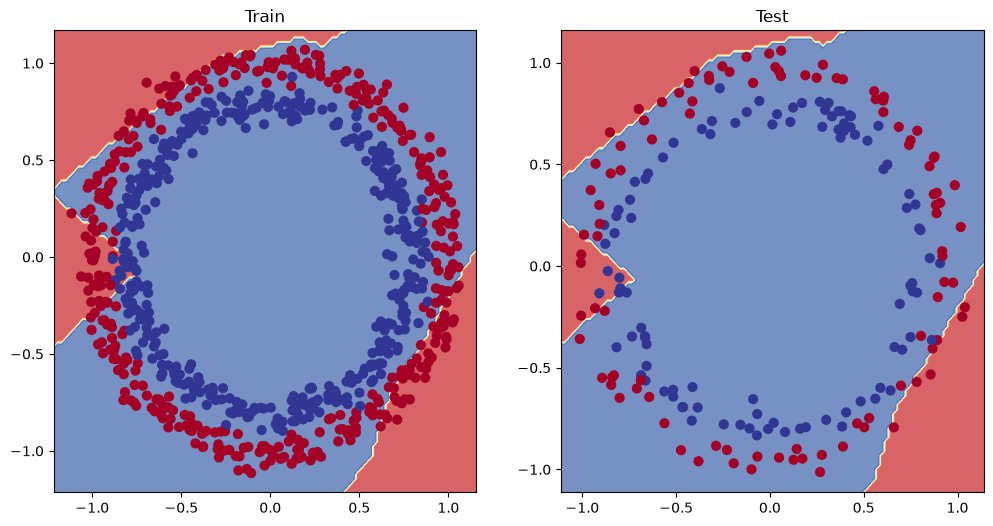

In [65]:
# plot decision boundaries for training and test set
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_2,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_2,X_test,y_test)

# Activation functions

In [66]:
x = torch.linspace(-15,15,100)
x

tensor([-15.0000, -14.6970, -14.3939, -14.0909, -13.7879, -13.4848, -13.1818,
        -12.8788, -12.5758, -12.2727, -11.9697, -11.6667, -11.3636, -11.0606,
        -10.7576, -10.4545, -10.1515,  -9.8485,  -9.5455,  -9.2424,  -8.9394,
         -8.6364,  -8.3333,  -8.0303,  -7.7273,  -7.4242,  -7.1212,  -6.8182,
         -6.5152,  -6.2121,  -5.9091,  -5.6061,  -5.3030,  -5.0000,  -4.6970,
         -4.3939,  -4.0909,  -3.7879,  -3.4848,  -3.1818,  -2.8788,  -2.5758,
         -2.2727,  -1.9697,  -1.6667,  -1.3636,  -1.0606,  -0.7576,  -0.4545,
         -0.1515,   0.1515,   0.4545,   0.7576,   1.0606,   1.3636,   1.6667,
          1.9697,   2.2727,   2.5758,   2.8788,   3.1818,   3.4848,   3.7879,
          4.0909,   4.3939,   4.6970,   5.0000,   5.3030,   5.6061,   5.9091,
          6.2121,   6.5152,   6.8182,   7.1212,   7.4242,   7.7273,   8.0303,
          8.3333,   8.6364,   8.9394,   9.2424,   9.5455,   9.8485,  10.1515,
         10.4545,  10.7576,  11.0606,  11.3636,  11.6667,  11.96

In [67]:
def relu(x):
    return torch.max(torch.tensor(0),x)

y = relu(x)
y 

tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.1515,  0.4545,  0.7576,  1.0606,  1.3636,  1.6667,
         1.9697,  2.2727,  2.5758,  2.8788,  3.1818,  3.4848,  3.7879,  4.0909,
         4.3939,  4.6970,  5.0000,  5.3030,  5.6061,  5.9091,  6.2121,  6.5152,
         6.8182,  7.1212,  7.4242,  7.7273,  8.0303,  8.3333,  8.6364,  8.9394,
         9.2424,  9.5455,  9.8485, 10.1515, 10.4545, 10.7576, 11.0606, 11.3636,
        11.6667, 11.9697, 12.2727, 12.5758, 12.8788, 13.1818, 13.4848, 13.7879,
        14.0909, 14.3939, 14.6970, 15.00

In [68]:

def tanh(x):
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))
y = tanh(x)
y

tensor([-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -0.9999, -0.9998, -0.9997, -0.9994, -0.9990, -0.9981, -0.9966,
        -0.9937, -0.9885, -0.9790, -0.9618, -0.9311, -0.8772, -0.7859, -0.6396,
        -0.4256, -0.1504,  0.1504,  0.4256,  0.6396,  0.7859,  0.8772,  0.9311,
         0.9618,  0.9790,  0.9885,  0.9937,  0.9966,  0.9981,  0.9990,  0.9994,
         0.9997,  0.9998,  0.9999,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  1.00

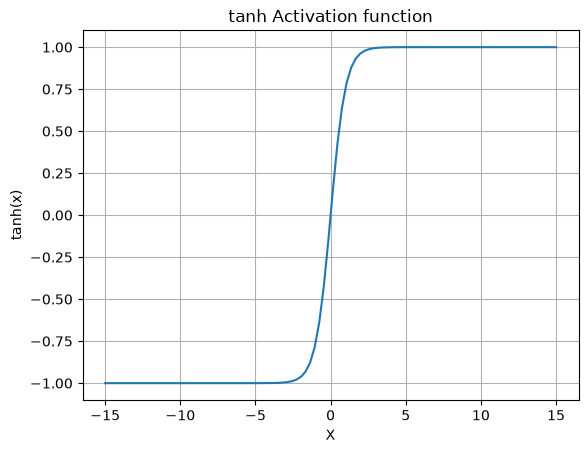

In [69]:
plt.plot(x.numpy(), y.numpy())
plt.title("tanh Activation function")
plt.xlabel("X")
plt.ylabel("tanh(x)")
plt.grid(True)
plt.show()

In [70]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))
y = sigmoid(x)
y

tensor([3.0590e-07, 4.1418e-07, 5.6078e-07, 7.5927e-07, 1.0280e-06, 1.3919e-06,
        1.8846e-06, 2.5516e-06, 3.4547e-06, 4.6776e-06, 6.3332e-06, 8.5749e-06,
        1.1610e-05, 1.5719e-05, 2.1283e-05, 2.8816e-05, 3.9015e-05, 5.2824e-05,
        7.1521e-05, 9.6833e-05, 1.3110e-04, 1.7750e-04, 2.4031e-04, 3.2534e-04,
        4.4045e-04, 5.9626e-04, 8.0714e-04, 1.0925e-03, 1.4786e-03, 2.0010e-03,
        2.7073e-03, 3.6621e-03, 4.9518e-03, 6.6929e-03, 9.0404e-03, 1.2201e-02,
        1.6449e-02, 2.2142e-02, 2.9746e-02, 3.9856e-02, 5.3212e-02, 7.0715e-02,
        9.3407e-02, 1.2242e-01, 1.5887e-01, 2.0365e-01, 2.5719e-01, 3.1917e-01,
        3.8828e-01, 4.6219e-01, 5.3781e-01, 6.1172e-01, 6.8083e-01, 7.4281e-01,
        7.9635e-01, 8.4113e-01, 8.7758e-01, 9.0659e-01, 9.2928e-01, 9.4679e-01,
        9.6014e-01, 9.7025e-01, 9.7786e-01, 9.8355e-01, 9.8780e-01, 9.9096e-01,
        9.9331e-01, 9.9505e-01, 9.9634e-01, 9.9729e-01, 9.9800e-01, 9.9852e-01,
        9.9891e-01, 9.9919e-01, 9.9940e-

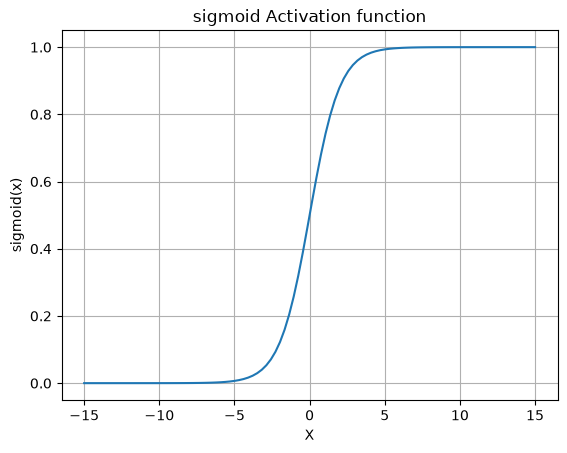

In [71]:
plt.plot(x.numpy(), y.numpy())
plt.title("sigmoid Activation function")
plt.xlabel("X")
plt.ylabel("sigmoid(x)")
plt.grid(True)
plt.show()

# Multi class classification problems

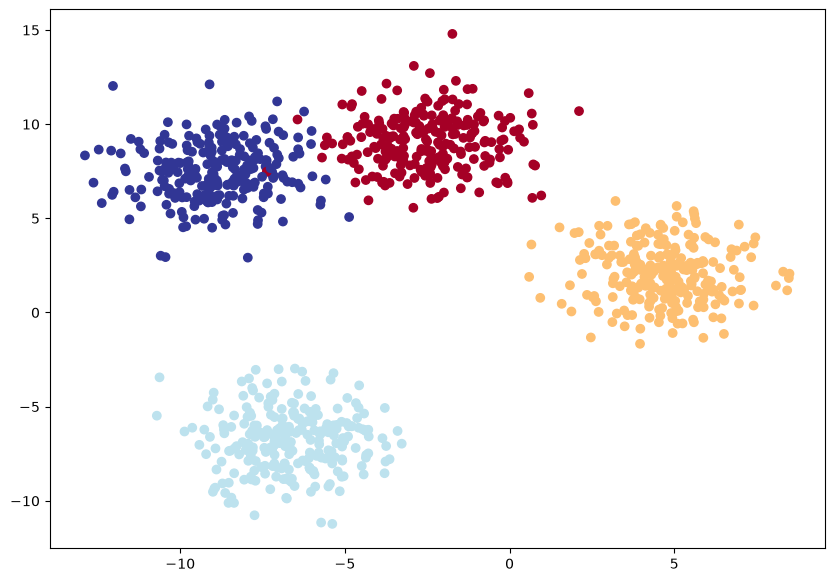

In [72]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


num_classes = 4
num_features = 2
random_seed = 42

x_blob, y_blob = make_blobs(n_samples=1000, n_features=num_features, centers=num_classes, cluster_std=1.5, random_state=random_seed)

# print(f"First 5 samples of X_blob : \n{X_blob[:5]}")
# print(f"First 5 samples of y_blob : \n{y_blob[:5]}")

# print(type(X_blob))
# print(type(y_blob))

x_blob = torch.from_numpy(x_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

x_blob_train, x_blob_test, y_blob_train, y_blob_test = train_test_split(x_blob, y_blob, test_size=0.2, random_state=random_seed)

plt.figure(figsize=(10,7))
plt.scatter(x_blob[:,0],x_blob[:,1],c=y_blob,cmap=plt.cm.RdYlBu)

In [73]:
x_blob.shape , 

(torch.Size([1000, 2]),)

In [74]:

print(f"First 5 samples of X_blob : \n{x_blob[:5]}")
print(f"First 5 samples of y_blob : \n{y_blob[:5]}")

First 5 samples of X_blob : 
tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]])
First 5 samples of y_blob : 
tensor([3, 2, 2, 1, 1])


In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [76]:
import torch
print(torch.__version__)

2.6.0+cu124


In [77]:
from torch import nn

class BlobModel(nn.Module):
    def __init__(self, input_features:int, output_features:int, hidden_units:int=8):
        super(BlobModel,self).__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features,out_features=hidden_units),
            # nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            # nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_features)
        )

    def forward(self,x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer_stack(x)
    

model_3 = BlobModel(input_features=num_features,output_features=num_classes).to(device)
model_3

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [78]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_3.parameters(), lr = 0.1)

In [79]:
test1 = x_blob_train.to(device)
test1[:5]

tensor([[ 5.0405,  3.3076],
        [-2.6249,  9.5260],
        [-8.5240, -9.0402],
        [-6.0262, -4.4375],
        [-3.3397,  7.2175]], device='cuda:0')

In [80]:
logits = model_3(test1[:5])
logits

tensor([[-1.2711, -0.6494, -1.4740, -0.7044],
        [ 0.2210, -1.5439,  0.0420,  1.1531],
        [ 2.8698,  0.9143,  3.3169,  1.4027],
        [ 1.9576,  0.3125,  2.2244,  1.1324],
        [ 0.5458, -1.2381,  0.4441,  1.1804]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [81]:
output_prob = torch.softmax(logits,dim=1)
output_prob

tensor([[0.1838, 0.3422, 0.1500, 0.3239],
        [0.2199, 0.0377, 0.1839, 0.5586],
        [0.3406, 0.0482, 0.5326, 0.0785],
        [0.3405, 0.0657, 0.4446, 0.1492],
        [0.2527, 0.0424, 0.2283, 0.4766]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

In [82]:
outputs = torch.argmax(output_prob,dim=1)
outputs

tensor([1, 3, 2, 2, 3], device='cuda:0')

In [83]:
torch.manual_seed(42)
epochs = 100

x_blob_train, y_blob_train = x_blob_train.to(device), y_blob_train.to(device)
x_blob_test, y_blob_test = x_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    
    model_3.train()

    optimizer.zero_grad()

    logits = model_3(x_blob_train)

    train_loss = loss_fn(logits, y_blob_train)

    train_loss.backward()

    optimizer.step()

    
    # validation step

    with torch.inference_mode():
        model_3.eval()
        
        logits = model_3(x_blob_test)
        test_loss = loss_fn(logits, y_blob_test)
        print(f"Epoch: {epoch}, Train Loss: {train_loss.item()}, Test Loss: {test_loss.item()}")

Epoch: 0, Train Loss: 1.0432369709014893, Test Loss: 0.5786146521568298
Epoch: 1, Train Loss: 0.5751853585243225, Test Loss: 0.4267239272594452
Epoch: 2, Train Loss: 0.4294021725654602, Test Loss: 0.3469548523426056
Epoch: 3, Train Loss: 0.3447754383087158, Test Loss: 0.2886488735675812
Epoch: 4, Train Loss: 0.28833097219467163, Test Loss: 0.24888034164905548
Epoch: 5, Train Loss: 0.24757038056850433, Test Loss: 0.2165883481502533
Epoch: 6, Train Loss: 0.21667498350143433, Test Loss: 0.19232995808124542
Epoch: 7, Train Loss: 0.19246906042099, Test Loss: 0.17194844782352448
Epoch: 8, Train Loss: 0.1730448305606842, Test Loss: 0.15570642054080963
Epoch: 9, Train Loss: 0.15716297924518585, Test Loss: 0.14187359809875488
Epoch: 10, Train Loss: 0.14397814869880676, Test Loss: 0.13037431240081787
Epoch: 11, Train Loss: 0.13289029896259308, Test Loss: 0.12048119306564331
Epoch: 12, Train Loss: 0.12346135824918747, Test Loss: 0.11201275140047073
Epoch: 13, Train Loss: 0.11536414921283722, Test

In [84]:
model_3.eval()
with torch.inference_mode():
    y_logits = model_3(x_blob_test)


print(x_blob_test[:3])
print(y_logits[:3])

tensor([[ 4.6675,  4.4878],
        [-7.9969,  6.8803],
        [-6.2801, -7.8571]], device='cuda:0')
tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711]], device='cuda:0')


In [85]:
prob = torch.softmax(y_logits, dim=1)
y_pred = torch.argmax(prob, dim=1)

print(y_pred[:3])
print(y_blob_test[:3])

tensor([1, 3, 2], device='cuda:0')
tensor([1, 3, 2], device='cuda:0')


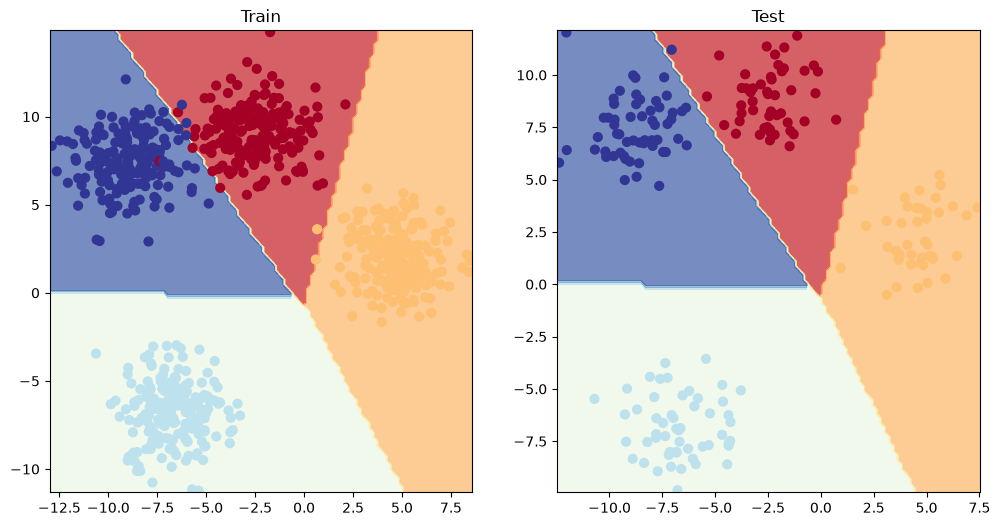

In [86]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, x_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, x_blob_test, y_blob_test)